# Task 4.5

**4.5 Predict antibody breadth - all variants (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Geo mean / Metric: Spearman correlation
* Full description: Geomean HAI across all variants at Day 28

---

**y-values:** log2-transformed; `np.exp2` to output raw titer geomean.

**5-fold cross-validation:** each participant's prediction is made by a model that never saw them during training.

In [1]:
import os

import joblib
import numpy as np
import pandas as pd

from model_utils import evaluate, predict_challenge

In [2]:
USE_GOOGLE_COLAB = False

if USE_GOOGLE_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    DATA_PATH = os.path.join(os.getcwd(), 'drive', 'MyDrive', 'DSE_260A', 'data', 'cleaned_data')
else:
    DATA_PATH = '../cleaned_data'

MODEL_PATH = 'models/task_4_5_model.pkl'
SUBMISSION_PATH = 'submission/task_4_5.csv'

In [3]:
train_participants = pd.read_csv(DATA_PATH + '/participants_cleaned.csv')
train_hai = pd.read_csv(DATA_PATH + '/hai_cleaned.csv')

# Data is pre-cleaned: one row per participant, HAI columns as HAI_{strain}_d{timepoint},
# participant columns as PART_{field}.
data = train_hai.merge(train_participants, on='participant_id', how='inner')
part_cols = [c for c in data.columns if c.startswith('PART_')]
print(f'Merged shape: {data.shape}')

# Challenge set: unseen participants we generate final submission predictions for.
challenge_participants = pd.read_csv(DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_data = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
print(f'Challenge shape: {challenge_data.shape}')

Merged shape: (3757, 199)
Challenge shape: (40, 21)


---

## Task 4.5 — Geo mean HAI across all variants (D28)

Samples: 3705   Features: 72
Spearman (5-fold CV): 0.616  (p-value: 0)
Model                                        RMSE        MSE      MAE   Spearman
Linear Regression (5-Fold CV)              1.3205     1.7436   1.0242     0.6155


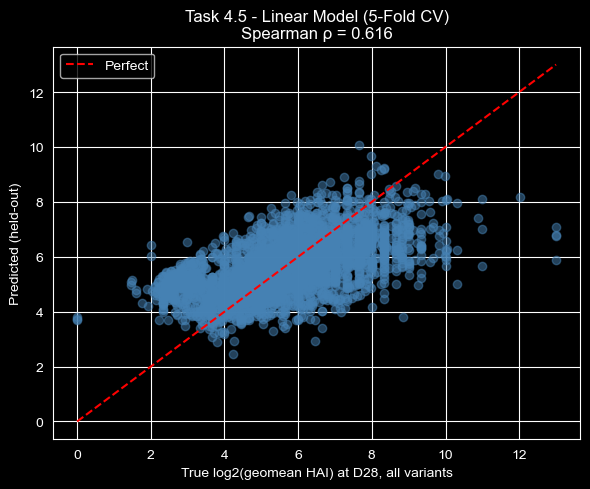

Model saved to models/task_4_5_model.pkl


In [4]:
all_d28_cols = [c for c in data.columns if c.startswith('HAI_') and c.endswith('_d28')]
all_d0_cols = [c for c in data.columns if c.startswith('HAI_') and c.endswith('_d0')]

# Target: mean of log2 HAI at D28 across every measured strain.
y_vals = data[all_d28_cols].mean(axis=1, skipna=True)
mask = y_vals.notna()
y_vals = y_vals[mask]

feature_cols = all_d0_cols + part_cols
X = data.loc[mask, feature_cols].copy()

y_pred_cv, model = evaluate(X, y_vals, 'Task 4.5', plot_color='steelblue',
                            y_axis_label='True log2(geomean HAI) at D28, all variants')

os.makedirs('models', exist_ok=True)
joblib.dump(model, MODEL_PATH)
print(f'Model saved to {MODEL_PATH}')

In [5]:
y_pred_challenge = predict_challenge(model, challenge_data, feature_cols)

results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.5*': np.exp2(y_pred_challenge),  # reverse log2 -> raw titer geomean
})
os.makedirs('submission', exist_ok=True)
results.to_csv(SUBMISSION_PATH, index=False)
results

,Participant_ID,Task_4.5*
0,2024_UGA.ID_077,59.609649
1,2024_UGA.ID_086,115.799662
2,2024_UGA.ID_128,204.011340
3,2024_UGA.ID_170,57.590690
4,2024_UGA.ID_179,42.432823
5,2024_UGA.ID_215,119.855742
6,2024_UGA.ID_219,110.702174
7,2024_UGA.ID_275,39.184603
8,2024_UGA.ID_295,39.907103
9,2024_UGA.ID_296,40.898499
